# RNA-FM vs RiNALMo — hg38 → mm39 output comparison

**Question:** now that the pipeline's core model switched from RNA-FM to RiNALMo (with re-calibration/stabilisation), is the annotation *completely different*, or does it *deviate but stay sane*? And **how** does it differ?

- **Old (RNA-FM):** `preprint_results/hg38_vs_mm39/` — the preprint snapshot.
- **New (RiNALMo):** `rinalmo_version_outputs/hg38_vs_mm39/`.

The reference annotation and chains are the same for both runs, so differences isolate the **model + its calibration**.

### What is / isn't comparable
- **Comparable:** counts, genomic coordinates, gene-level overlap, biotype composition, island lengths, and the *ranking* of scores.
- **NOT directly comparable on scale:** the `mmd_score` / `diag_mmd` / `chain1_mmd` columns. Under RNA-FM these are true MMD distances; under RiNALMo the same columns carry a cosine/Smith-Waterman-derived distance. Same column name, different numeric meaning — so we compare *distributions and ranks*, never "is 0.05 the same threshold".

### Tracks analysed
1. **Short ncRNA** (≤160 nt) — local embedding match.
2. **Island alignment** (lncRNA) — matched structured sub-regions.
3. **Raw island scanning** — the upstream detector, to see how much divergence is *finding* vs *matching*.

In [121]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

sys.path.insert(0, str(Path.cwd()))          # notebooks/ is cwd; import local helpers
import _compare_helpers as H

ROOT = Path('/Users/Bogdan.Kirilenko/Developer/CURIA_pipeline')
OLD = ROOT / 'preprint_results/hg38_vs_mm39'          # RNA-FM (preprint)
NEW = ROOT / 'rinalmo_version_outputs/hg38_vs_mm39'   # RiNALMo (new)
OLD_LBL, NEW_LBL = 'RNA-FM (old)', 'RiNALMo (new)'
C_OLD, C_NEW = '#8888cc', '#cc6644'

pd.set_option('display.width', 140)
pd.set_option('display.max_columns', 40)

# ---- load every table once ----
short_old = H.read_details(OLD);      short_new = H.read_details(NEW)
aln_old   = H.read_alignment(OLD);    aln_new   = H.read_alignment(NEW)
aq_old = H.read_bed12(OLD, 'aligned_query_islands.bed'); aq_new = H.read_bed12(NEW, 'aligned_query_islands.bed')
rq_old = H.read_bed12(OLD, 'raw_query_islands.bed');     rq_new = H.read_bed12(NEW, 'raw_query_islands.bed')
rr_old = H.read_bed12(OLD, 'raw_reference_islands.bed'); rr_new = H.read_bed12(NEW, 'raw_reference_islands.bed')

print('short ncRNA rows :', len(short_old), 'vs', len(short_new))
print('island aln rows  :', len(aln_old), 'vs', len(aln_new))
print('aligned q islands:', len(aq_old), 'vs', len(aq_new))
print('raw q islands    :', len(rq_old), 'vs', len(rq_new))
print('raw r islands    :', len(rr_old), 'vs', len(rr_new))

short ncRNA rows : 2806 vs 2683
island aln rows  : 30412 vs 10736
aligned q islands: 15159 vs 7641
raw q islands    : 109006 vs 44245
raw r islands    : 66087 vs 36788


## A. Short ncRNA track (<=160 nt)

Join key = `gene_id`. We ask: which genes are annotated by both, only old, only new; is the composition preserved across biotypes; and for the genes both agree on, do they land in the **same place** with a consistent score ranking.

genes  old=2741  new=2641  shared=2641  old-only=100  new-only=0
retention (shared/old) = 96.4%   ;   new set subset of old? True

                  old   new  lost retention
biotype                                    
miRNA            1256  1223    33       97%
snoRNA            442   418    24       95%
snRNA             334   327     7       98%
misc_RNA          266   258     8       97%
tRNA              239   213    26       89%
rRNA_pseudogene   143   143     0      100%
lncRNA             36    36     0      100%
scaRNA             15    15     0      100%
sRNA                4     2     2       50%
rRNA                3     3     0      100%
ribozyme            2     2     0      100%
vault_RNA           1     1     0      100%


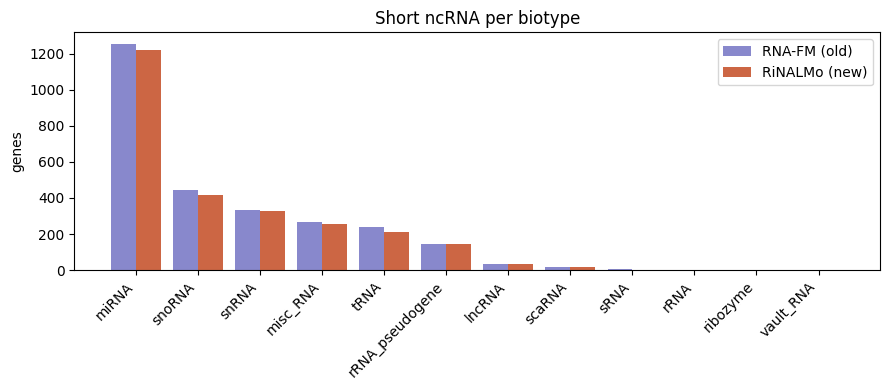

In [122]:
# A1 — gene-set overlap and biotype-level retention
g_old, g_new = set(short_old.gene_id), set(short_new.gene_id)
shared = g_old & g_new
print(f'genes  old={len(g_old)}  new={len(g_new)}  shared={len(shared)}  old-only={len(g_old-g_new)}  new-only={len(g_new-g_old)}')
print(f'retention (shared/old) = {len(shared)/len(g_old):.1%}   ;   new set subset of old? {g_new <= g_old}')

# biotype composition (one biotype per gene)
bt_old = short_old.drop_duplicates('gene_id').set_index('gene_id').biotype
bt_new = short_new.drop_duplicates('gene_id').set_index('gene_id').biotype
bt = pd.DataFrame({'old': bt_old.value_counts(), 'new': bt_new.value_counts()}).fillna(0).astype(int)
bt['lost'] = bt['old'] - bt['new']
bt['retention'] = (bt['new'] / bt['old']).map('{:.0%}'.format)
bt = bt.sort_values('old', ascending=False)
print(); print(bt)

fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(bt)); w = 0.4
ax.bar(x - w/2, bt['old'], w, label=OLD_LBL, color=C_OLD)
ax.bar(x + w/2, bt['new'], w, label=NEW_LBL, color=C_NEW)
ax.set_xticks(x); ax.set_xticklabels(bt.index, rotation=45, ha='right')
ax.set_ylabel('genes'); ax.set_title('Short ncRNA per biotype'); ax.legend()
plt.tight_layout(); plt.show()

shared genes compared: 2641
same chromosome         : 99.6%
reciprocal overlap >0   : 99.2%
reciprocal overlap >=0.5: 98.9%
reciprocal overlap >=0.9: 91.4%
median reciprocal overlap: 0.962

score Spearman rho (shared genes): 0.913  (p=0.0e+00)  -- ranking agreement despite scale change


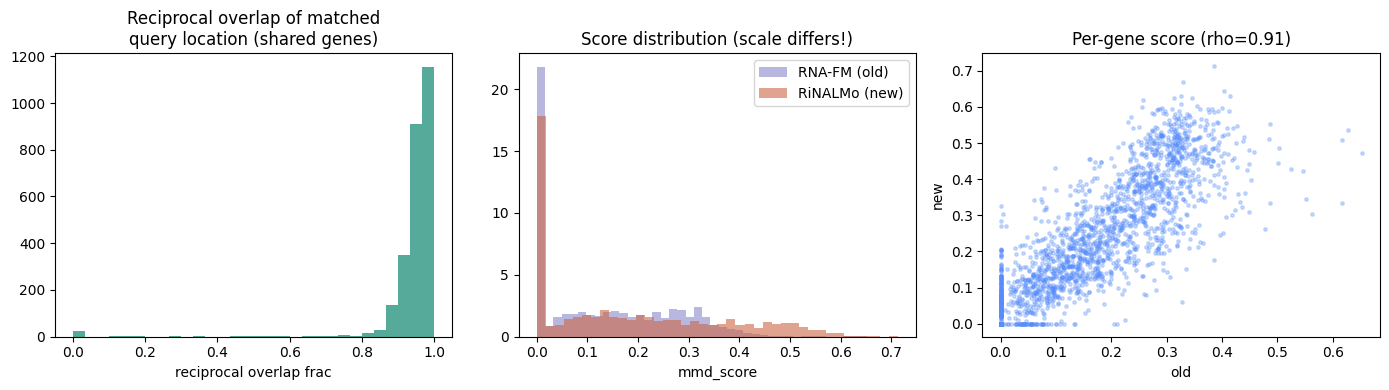

In [123]:
# A2 — do shared genes land in the same place, and do scores rank-agree?
# representative prediction per gene = its best (lowest-distance) row
def best_per_gene(df):
    return df.sort_values('mmd_score').drop_duplicates('gene_id').set_index('gene_id')

bo, bn = best_per_gene(short_old), best_per_gene(short_new)
j = bo.join(bn, lsuffix='_o', rsuffix='_n', how='inner')

j['recip_ov'] = [H.reciprocal_overlap(co, so, eo, cn, sn, en)
                 for co, so, eo, cn, sn, en in
                 zip(j.chrom_o, j.start_o, j.end_o, j.chrom_n, j.start_n, j.end_n)]
same_chrom = (j.chrom_o == j.chrom_n).mean()
print(f'shared genes compared: {len(j)}')
print(f'same chromosome         : {same_chrom:.1%}')
print(f'reciprocal overlap >0   : {(j.recip_ov > 0).mean():.1%}')
print(f'reciprocal overlap >=0.5: {(j.recip_ov >= 0.5).mean():.1%}')
print(f'reciprocal overlap >=0.9: {(j.recip_ov >= 0.9).mean():.1%}')
print(f'median reciprocal overlap: {j.recip_ov.median():.3f}')

rho, p = spearmanr(j.mmd_score_o, j.mmd_score_n)
print(f'\nscore Spearman rho (shared genes): {rho:.3f}  (p={p:.1e})  -- ranking agreement despite scale change')

fig, ax = plt.subplots(1, 3, figsize=(14, 4))
ax[0].hist(j.recip_ov, bins=30, color='#5a9')
ax[0].set_title('Reciprocal overlap of matched\nquery location (shared genes)'); ax[0].set_xlabel('reciprocal overlap frac')
ax[1].hist(short_old.mmd_score, bins=40, alpha=.6, label=OLD_LBL, color=C_OLD, density=True)
ax[1].hist(short_new.mmd_score, bins=40, alpha=.6, label=NEW_LBL, color=C_NEW, density=True)
ax[1].set_title('Score distribution (scale differs!)'); ax[1].set_xlabel('mmd_score'); ax[1].legend()
ax[2].scatter(j.mmd_score_o, j.mmd_score_n, s=6, alpha=.3)
ax[2].set_title(f'Per-gene score (rho={rho:.2f})'); ax[2].set_xlabel('old'); ax[2].set_ylabel('new')
plt.tight_layout(); plt.show()

## B. Island alignment track (lncRNA)

This is where the models are expected to diverge most: RNA-FM matched islands by windowed-MMD (many redundant candidate windows), while RiNALMo matches by a nucleotide-resolution cosine/Smith-Waterman dotplot with quality gates (fewer, tighter calls). So raw counts *will* drop. The real questions:
1. Which **genes** still get an aligned island (gained / lost / shared)?
2. For shared genes, do the aligned islands cover the **same query locus** (bp Jaccard)?
3. How do per-gene island counts and island lengths shift?

genes with an aligned island:
  old=15159  new=7641  shared=5742  old-only=9417  new-only=1899
  of old genes retained: 37.9%   ;  of new genes that are also old: 75.1%
  Jaccard of gene sets  : 0.337


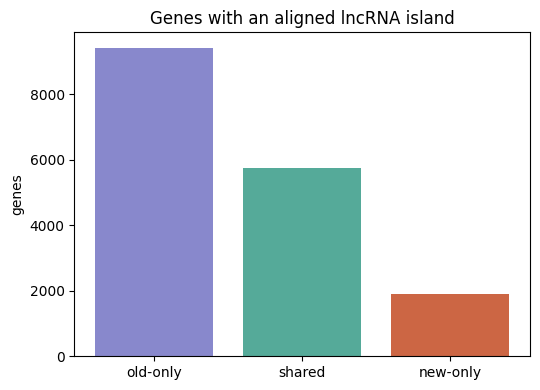

In [124]:
# B1 — gene-set overlap for genes that received an aligned island
aq_old = aq_old.assign(gene=aq_old.name.map(H.gene_of_aligned))
aq_new = aq_new.assign(gene=aq_new.name.map(H.gene_of_aligned))
gi_old, gi_new = set(aq_old.gene), set(aq_new.gene)
shared_i = gi_old & gi_new
print('genes with an aligned island:')
print(f'  old={len(gi_old)}  new={len(gi_new)}  shared={len(shared_i)}  old-only={len(gi_old-gi_new)}  new-only={len(gi_new-gi_old)}')
print(f'  of old genes retained: {len(shared_i)/len(gi_old):.1%}   ;  of new genes that are also old: {len(shared_i)/len(gi_new):.1%}')
print(f'  Jaccard of gene sets  : {len(shared_i)/len(gi_old | gi_new):.3f}')

fig, ax = plt.subplots(figsize=(5.5, 4))
try:
    from matplotlib_venn import venn2
    venn2([gi_old, gi_new], set_labels=(OLD_LBL, NEW_LBL), set_colors=(C_OLD, C_NEW), ax=ax)
except Exception:
    ax.bar(['old-only', 'shared', 'new-only'],
           [len(gi_old-gi_new), len(shared_i), len(gi_new-gi_old)],
           color=['#8888cc', '#5a9', '#cc6644'])
    ax.set_ylabel('genes')
ax.set_title('Genes with an aligned lncRNA island')
plt.tight_layout(); plt.show()

islands per gene (shared genes):
        old    new
mean   2.51   1.47
50%    2.00   1.00
max   48.00  19.00

same count: 38.2%   new<old: 53.2%   new>old: 8.6%


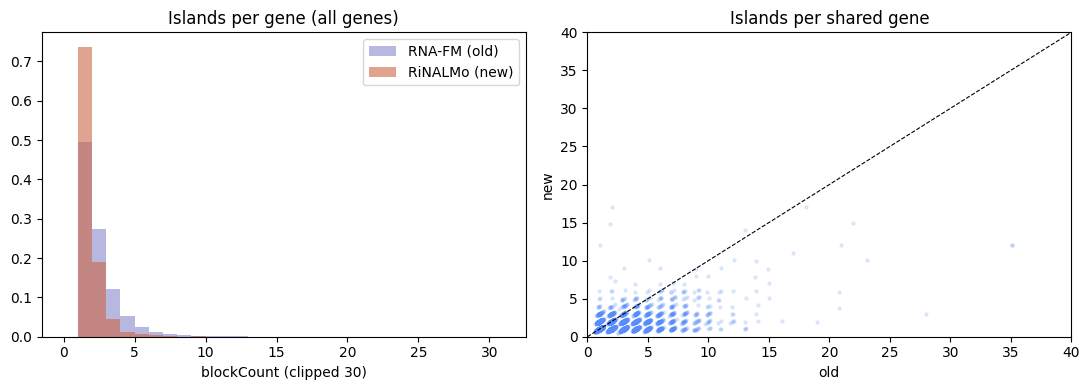

In [125]:
# B2 — per-gene number of aligned islands (blockCount), on shared genes
cnt_old = aq_old.set_index('gene').blockCount
cnt_new = aq_new.set_index('gene').blockCount
cc = pd.DataFrame({'old': cnt_old, 'new': cnt_new}).loc[sorted(shared_i)]
print('islands per gene (shared genes):')
print(cc.describe().loc[['mean', '50%', 'max']].round(2))
print(f"\nsame count: {(cc['old'] == cc['new']).mean():.1%}   new<old: {(cc['new'] < cc['old']).mean():.1%}   new>old: {(cc['new'] > cc['old']).mean():.1%}")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
mx = int(min(30, cc.max().max()))
ax[0].hist(cnt_old.clip(upper=mx), bins=range(mx+2), alpha=.6, label=OLD_LBL, color=C_OLD, density=True)
ax[0].hist(cnt_new.clip(upper=mx), bins=range(mx+2), alpha=.6, label=NEW_LBL, color=C_NEW, density=True)
ax[0].set_title('Islands per gene (all genes)'); ax[0].set_xlabel(f'blockCount (clipped {mx})'); ax[0].legend()
jit = np.random.default_rng(0).normal(0, .12, len(cc))
ax[1].scatter(cc['old']+jit, cc['new']+jit, s=5, alpha=.15)
lim = cc.values.max(); ax[1].plot([0, lim], [0, lim], 'k--', lw=.8)
ax[1].set_xlim(0, min(40, lim)); ax[1].set_ylim(0, min(40, lim))
ax[1].set_title('Islands per shared gene'); ax[1].set_xlabel('old'); ax[1].set_ylabel('new')
plt.tight_layout(); plt.show()

shared genes: 5742
same chromosome    : 98.2%
locus Jaccard >0   : 45.3%
locus Jaccard >=0.1: 35.1%
locus Jaccard >=0.5: 3.7%
median / mean Jaccard: 0.000 / 0.106


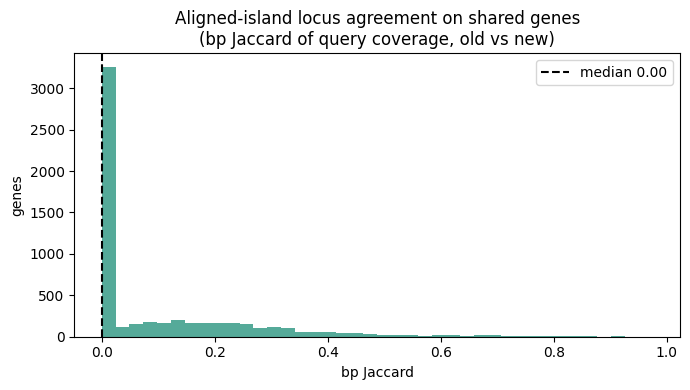

In [126]:
# B3 — do the aligned islands cover the SAME query locus? (bp Jaccard per shared gene)
def gene_loc(df):
    d = {}
    for r in df.itertuples(index=False):
        d[r.gene] = (r.chrom, H.blocks_of(r._asdict()))
    return d

loc_old, loc_new = gene_loc(aq_old), gene_loc(aq_new)
rows = []
for g in shared_i:
    co, bo = loc_old[g]; cn, bn = loc_new[g]
    rows.append((g, co == cn, H.jaccard(co, bo, cn, bn)))
jac = pd.DataFrame(rows, columns=['gene', 'same_chrom', 'jaccard'])

print(f'shared genes: {len(jac)}')
print(f'same chromosome    : {jac.same_chrom.mean():.1%}')
print(f'locus Jaccard >0   : {(jac.jaccard > 0).mean():.1%}')
print(f'locus Jaccard >=0.1: {(jac.jaccard >= 0.1).mean():.1%}')
print(f'locus Jaccard >=0.5: {(jac.jaccard >= 0.5).mean():.1%}')
print(f'median / mean Jaccard: {jac.jaccard.median():.3f} / {jac.jaccard.mean():.3f}')

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(jac.jaccard, bins=40, color='#5a9')
ax.axvline(jac.jaccard.median(), color='k', ls='--', label=f'median {jac.jaccard.median():.2f}')
ax.set_title('Aligned-island locus agreement on shared genes\n(bp Jaccard of query coverage, old vs new)')
ax.set_xlabel('bp Jaccard'); ax.set_ylabel('genes'); ax.legend()
plt.tight_layout(); plt.show()

nearest new->old island gap, shared genes on same chrom (bp):
    overlap: 46.4%
     <= 100: 59.3%
     <= 500: 79.9%
    <= 1000: 85.6%
    <= 5000: 92.4%
  median gap: 26 bp    90th pct: 2406 bp


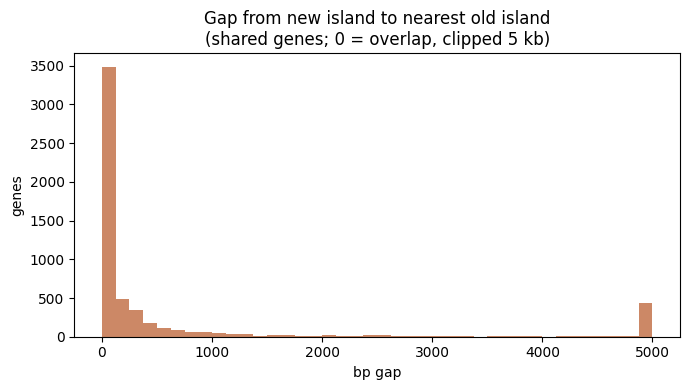

In [127]:
# B3b — proximity: islands are ~100 bp footprints inside large loci, so bp-Jaccard
# under-counts. Measure, per shared gene, the gap from each NEW island to the
# nearest OLD island (0 = overlap). Small gaps => same region, just re-placed.
def nearest_gap(bo, bn):
    # min gap between any interval in bn and any in bo; 0 if they overlap
    best = np.inf
    for s2, e2 in bn:
        for s1, e1 in bo:
            if e1 > s2 and e2 > s1:
                return 0
            gap = s1 - e2 if s1 >= e2 else s2 - e1
            best = min(best, gap)
    return best

gaps = []
for g in shared_i:
    co, bo = loc_old[g]; cn, bn = loc_new[g]
    if co != cn:
        gaps.append(np.nan); continue
    gaps.append(nearest_gap(bo, bn))
gaps = pd.Series(gaps, dtype=float)
finite = gaps.dropna()
print('nearest new->old island gap, shared genes on same chrom (bp):')
for thr in [0, 100, 500, 1000, 5000]:
    lab = 'overlap' if thr == 0 else f'<= {thr}'
    print(f'  {lab:>9}: {(finite <= thr).mean():.1%}')
print(f'  median gap: {finite.median():.0f} bp    90th pct: {finite.quantile(.9):.0f} bp')

fig, ax = plt.subplots(figsize=(7, 4))
clip = finite.clip(upper=5000)
ax.hist(clip, bins=40, color='#c86')
ax.set_title('Gap from new island to nearest old island\n(shared genes; 0 = overlap, clipped 5 kb)')
ax.set_xlabel('bp gap'); ax.set_ylabel('genes')
plt.tight_layout(); plt.show()

aligned-island footprint length (bp):
           old      new
count  30380.0  10727.0
mean     121.8    172.3
50%      108.0    148.0
max      908.0   1191.0


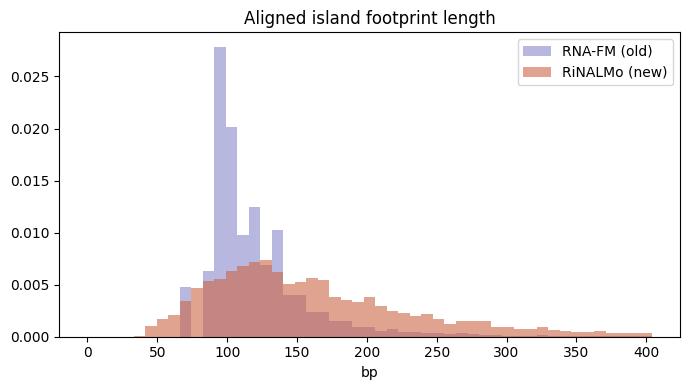

In [128]:
# B4 — aligned-island footprint length (individual block sizes)
def block_sizes(df):
    out = []
    for s in df.blockSizes:
        out.extend(int(x) for x in str(s).rstrip(',').split(',') if x != '')
    return np.array(out)

lo, ln = block_sizes(aq_old), block_sizes(aq_new)
print('aligned-island footprint length (bp):')
print(pd.DataFrame({'old': pd.Series(lo).describe(), 'new': pd.Series(ln).describe()}).round(1).loc[['count','mean','50%','max']])

fig, ax = plt.subplots(figsize=(7, 4))
b = np.linspace(0, np.percentile(np.concatenate([lo, ln]), 99), 50)
ax.hist(lo, bins=b, alpha=.6, label=OLD_LBL, color=C_OLD, density=True)
ax.hist(ln, bins=b, alpha=.6, label=NEW_LBL, color=C_NEW, density=True)
ax.set_title('Aligned island footprint length'); ax.set_xlabel('bp'); ax.legend()
plt.tight_layout(); plt.show()

## C. Raw island scanning (upstream detector)

Before alignment, each genome is scanned for structured islands. Comparing the *raw* island sets tells us how much of the downstream divergence originates in **finding** (the scanner: different window/stride/threshold + dual-PCA for RiNALMo) versus in **matching** (the aligner). If raw counts already halve, the aligner is not the main driver.

RAW island scanning:
            islands    genes  med_len  mean_len  total_Mb islands_ratio_new_old
query_old  109006.0  30415.0    136.0     170.3     18.56                      
query_new   44245.0  19458.0    288.0     330.3     14.62                      
ref_old     66087.0  21656.0    120.0     133.4      8.82                      
ref_new     36788.0  15197.0    128.0     165.7      6.09                      

raw query islands new/old = 0.41   raw ref islands new/old = 0.56
aligned islands   new/old = 0.50   => most of the drop is already present in the RAW scan (finding), not the aligner


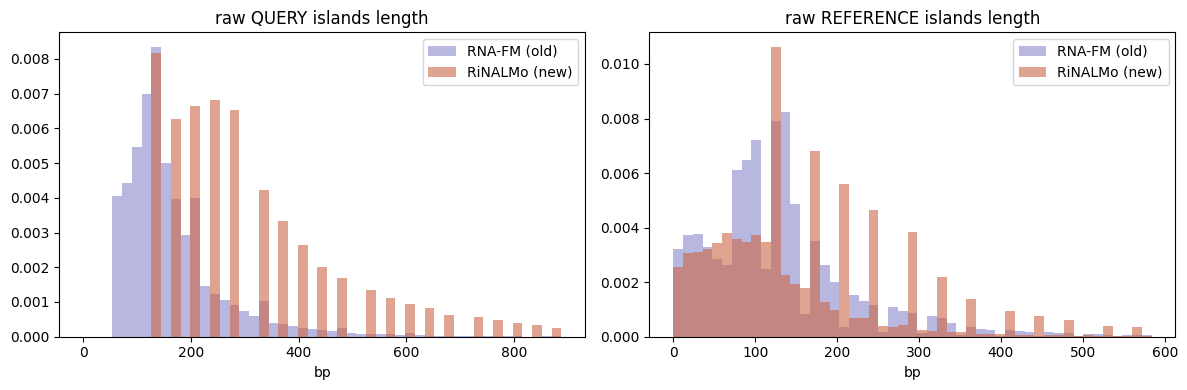

In [129]:
# C1 — raw island counts, lengths, and genes touched (query + reference sides)
def raw_stats(df, side):
    genes = df.name.map(H.gene_of_raw).nunique()
    length = (df.end - df.start)
    return {'islands': len(df), 'genes': genes, 'med_len': length.median(),
            'mean_len': round(length.mean(), 1), 'total_Mb': round(length.sum()/1e6, 2)}

tbl = pd.DataFrame({
    'query_old':  raw_stats(rq_old, 'q'), 'query_new':  raw_stats(rq_new, 'q'),
    'ref_old':    raw_stats(rr_old, 'r'), 'ref_new':    raw_stats(rr_new, 'r'),
}).T
tbl['islands_ratio_new_old'] = ''
print('RAW island scanning:'); print(tbl)
print(f"\nraw query islands new/old = {len(rq_new)/len(rq_old):.2f}   raw ref islands new/old = {len(rr_new)/len(rr_old):.2f}")
print(f"aligned islands   new/old = {len(aq_new)/len(aq_old):.2f}   => most of the drop is already present in the RAW scan (finding), not the aligner")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for a, (o, n, ttl) in zip(ax, [(rq_old, rq_new, 'raw QUERY islands'), (rr_old, rr_new, 'raw REFERENCE islands')]):
    b = np.linspace(0, np.percentile(np.concatenate([(o.end-o.start), (n.end-n.start)]), 99), 50)
    a.hist(o.end-o.start, bins=b, alpha=.6, label=OLD_LBL, color=C_OLD, density=True)
    a.hist(n.end-n.start, bins=b, alpha=.6, label=NEW_LBL, color=C_NEW, density=True)
    a.set_title(f'{ttl} length'); a.set_xlabel('bp'); a.legend()
plt.tight_layout(); plt.show()

## D. Synthesis — how different, and how?

In [130]:
# D1 — compact deviation scorecard
summary = pd.DataFrame([
    ['Short ncRNA', 'genes old / new',            f'{len(g_old)} / {len(g_new)}'],
    ['Short ncRNA', 'gene-set Jaccard',           f'{len(g_old & g_new)/len(g_old | g_new):.3f}'],
    ['Short ncRNA', 'new is subset of old',       str(g_new <= g_old)],
    ['Short ncRNA', 'shared genes: same locus (recip-ov>=0.5)', f'{(j.recip_ov>=0.5).mean():.1%}'],
    ['Short ncRNA', 'shared genes: score Spearman rho', f'{spearmanr(j.mmd_score_o, j.mmd_score_n)[0]:.2f}'],
    ['Islands',     'genes old / new',            f'{len(gi_old)} / {len(gi_new)}'],
    ['Islands',     'gene-set Jaccard',           f'{len(shared_i)/len(gi_old | gi_new):.3f}'],
    ['Islands',     'old genes retained',         f'{len(shared_i)/len(gi_old):.1%}'],
    ['Islands',     'new genes also in old',      f'{len(shared_i)/len(gi_new):.1%}'],
    ['Islands',     'shared genes: same chrom',   f'{jac.same_chrom.mean():.1%}'],
    ['Islands',     'shared genes: island within 500bp of old', f'{(finite<=500).mean():.1%}'],
    ['Islands',     'shared genes: median gap',   f'{finite.median():.0f} bp'],
    ['Islands',     'islands/gene old -> new (median)', f'{cnt_old.median():.0f} -> {cnt_new.median():.0f}'],
    ['Islands',     'footprint len old -> new (median bp)', f'{pd.Series(lo).median():.0f} -> {pd.Series(ln).median():.0f}'],
    ['Raw scan',    'raw query islands new/old',  f'{len(rq_new)/len(rq_old):.2f}x'],
    ['Raw scan',    'raw ref islands new/old',    f'{len(rr_new)/len(rr_old):.2f}x'],
], columns=['track', 'metric', 'value'])
pd.set_option('display.max_colwidth', 60)
print(summary.to_string(index=False))

      track                                   metric        value
Short ncRNA                          genes old / new  2741 / 2641
Short ncRNA                         gene-set Jaccard        0.964
Short ncRNA                     new is subset of old         True
Short ncRNA shared genes: same locus (recip-ov>=0.5)        98.9%
Short ncRNA         shared genes: score Spearman rho         0.91
    Islands                          genes old / new 15159 / 7641
    Islands                         gene-set Jaccard        0.337
    Islands                       old genes retained        37.9%
    Islands                    new genes also in old        75.1%
    Islands                 shared genes: same chrom        98.2%
    Islands shared genes: island within 500bp of old        79.9%
    Islands                 shared genes: median gap        26 bp
    Islands         islands/gene old -> new (median)       2 -> 1
    Islands     footprint len old -> new (median bp)   108 -> 148
   Raw sca

### Verdict: *deviates, but not crazy* — and the deviation is interpretable

**Short ncRNA track — essentially reproduced.**
- New set is a strict **subset** of old (gene Jaccard 0.96), losing ~3.6% of genes, uniformly across biotypes (no biotype collapses). No new short genes appear.
- Where both agree, they agree **hard**: 98.9% of shared genes land at the same query locus (reciprocal overlap >=0.5; median 0.96) and the scores rank-correlate at rho=0.91 despite the score *scale* being different between models.
- Read: RiNALMo reproduces the short-ncRNA calls and is marginally more conservative. Not a behaviour change.

**Island (lncRNA) track — same idea, tighter and shifted, more conservative.**
- Roughly **half** as many genes get an aligned island (15.2k -> 7.6k; gene Jaccard 0.34). But this is *not* chaos: 75% of the new genes were also called old, and among the ~9.4k 'lost' genes most simply fall below RiNALMo's stricter gates.
- On shared genes it is **not relocating** the annotation: 98% same chromosome, median island-to-nearest-old-island gap **26 bp**, 80% within 500 bp. The low bp-Jaccard (median 0) is an artifact of ~100–150 bp footprints scattered across large loci, not disagreement about *where* the island is.
- Islands are **fewer per gene** (median 2 -> 1) and **longer** (median footprint 108 -> 148 bp; raw 136 -> 288 bp) — consistent with the wider scan window (W128 vs W72) and merged overlap-labeling.
- **Attribution:** the ~2x reduction is already present in the **raw scan** (query 0.41x, ref 0.56x), so it comes from the *finding* stage (new window/stride/threshold + dual-PCA), not the aligner (aligned 0.50x tracks the raw ratio).

**Bottom line.** Not 'completely different'. Short ncRNA is near-identical; lncRNA islands are the same regions found more conservatively and with longer/fewer footprints. The right next step before concluding is a **truth-referenced** check (recall of real mm39 ncRNA / overlap with GENCODE+tRNA annotations via `preprint/island_annotation_overlap.ipynb`) to decide whether 'fewer islands' means *lost recall* or *dropped noise* — a raw count drop alone can't tell those apart.

> **Caveat retained:** `mmd_score` / `diag_mmd` / `chain1_mmd` are not on the same numeric scale across models; only ranks and distribution shapes were compared here.

## E. Truth-referenced check — lost recall or dropped noise?

A raw count drop can't distinguish *precision up* (RiNALMo dropped spurious islands) from *recall down* (it lost real ones). We anchor to **real mm39 annotation**: GENCODE vM38 transcripts + GtRNAdb tRNAs. For each island we take the best exonic-bp overlap with any annotated transcript.

Three questions:
1. **Precision proxy** — do RiNALMo's islands overlap real annotations at a *higher rate* than RNA-FM's? (per-island, on the raw scan)
2. **The decisive test** — split the OLD aligned islands into genes RiNALMo **kept** vs **dropped**. If the dropped ones overlap annotation far *less*, RiNALMo shed noise; if they overlap just as much, it lost real signal. Same split for the genes RiNALMo **added**.
3. **Recall proxy** — how many *distinct* real annotation features does each model recover?

*Truth is loose:* 'any GENCODE overlap' includes protein-coding neighbours, so we also report a **non-coding-only** truth (GENCODE biotype != protein_coding, plus all tRNAs).

In [131]:
# E1 — load truth annotations + define island->annotation overlap
from pyrion.io.bed import read_bed12_file
from pyrion.ops.interval_ops import intersect_intervals

TRUTH = ROOT / 'input_data/mm39_annotation_validation'
gencode = read_bed12_file(str(TRUTH / 'mm39_gencode_all_transcripts.bed'))
trna    = read_bed12_file(str(TRUTH / 'mm39-tRNAs.bed'))
gmeta   = pd.read_csv(TRUTH / 'mm39_gencode_metadata.tsv', sep='\t')
nc_ids  = set(gmeta.loc[gmeta.transcript_biotype != 'protein_coding', 'transcript_id'])
print(f'GENCODE {len(gencode):,}  tRNA {len(trna):,}  non-coding GENCODE ids {len(nc_ids):,}')

def _blen(arr):
    return int(np.sum(arr[:, 1].astype('int64') - arr[:, 0].astype('int64')))

def _best_bp(island_ex, coll, gi):
    best = best_nc = 0; hits = []
    for t in coll.get_transcripts_in_interval(gi):
        r = intersect_intervals(island_ex, t.exons())
        if len(r):
            bp = _blen(r)
            if bp > 0:
                hits.append(t.id)
                best = max(best, bp)
                if t.id in nc_ids:
                    best_nc = max(best_nc, bp)
    return best, best_nc, hits

def overlap_islands(islands, gene_fn, label=''):
    rows = []; hits_all = set(); hits_nc = set()
    n = len(islands); step = max(1, n // 8)
    for i, isl in enumerate(islands):
        if i % step == 0:
            print(f'  {label}: {i:,}/{n:,}')
        ex = isl.exons(); L = _blen(ex); gi = isl.transcript_interval
        g_bp, g_nc, g_hits = _best_bp(ex, gencode, gi)
        t_bp, _, t_hits = _best_bp(ex, trna, gi)
        comb, comb_nc = max(g_bp, t_bp), max(g_nc, t_bp)
        hits_all.update(g_hits); hits_all.update(t_hits)
        hits_nc.update(h for h in g_hits if h in nc_ids); hits_nc.update(t_hits)
        rows.append((isl.id, gene_fn(isl.id), L, comb, comb_nc,
                     comb / L if L else 0.0, comb_nc / L if L else 0.0))
    df = pd.DataFrame(rows, columns=['id', 'gene', 'len', 'ov_bp', 'ov_nc_bp', 'pct', 'pct_nc'])
    df['any'] = df.ov_bp > 0; df['any_nc'] = df.ov_nc_bp > 0
    df['o50'] = df.pct >= 0.5; df['o50_nc'] = df.pct_nc >= 0.5
    return df, hits_all, hits_nc

print('helpers ready')

GENCODE 278,326  tRNA 1,137  non-coding GENCODE ids 219,679
helpers ready


In [132]:
# E2 — compute island->annotation overlap on the ALIGNED (final) islands, old & new
# per-transcript overlap gives both the precision rate and the set of real features hit (recall).
aq_old_tc = read_bed12_file(str(H.resolve(OLD, 'aligned_query_islands.bed')))
aq_new_tc = read_bed12_file(str(H.resolve(NEW, 'aligned_query_islands.bed')))

ov_old, hits_old, hits_nc_old = overlap_islands(aq_old_tc, H.gene_of_aligned, 'aligned old')
ov_new, hits_new, hits_nc_new = overlap_islands(aq_new_tc, H.gene_of_aligned, 'aligned new')

# tag each gene by how the model sets relate (shared / old-only / new-only)
ov_old['grp'] = np.where(ov_old.gene.isin(shared_i), 'retained (shared)', 'dropped (old-only)')
ov_new['grp'] = np.where(ov_new.gene.isin(shared_i), 'retained (shared)', 'added (new-only)')
print('\ndone:', len(ov_old), 'old genes,', len(ov_new), 'new genes')

  aligned old: 0/15,159
  aligned old: 1,894/15,159
  aligned old: 3,788/15,159
  aligned old: 5,682/15,159
  aligned old: 7,576/15,159
  aligned old: 9,470/15,159
  aligned old: 11,364/15,159
  aligned old: 13,258/15,159
  aligned old: 15,152/15,159
  aligned new: 0/7,641
  aligned new: 955/7,641
  aligned new: 1,910/7,641
  aligned new: 2,865/7,641
  aligned new: 3,820/7,641
  aligned new: 4,775/7,641
  aligned new: 5,730/7,641
  aligned new: 6,685/7,641
  aligned new: 7,640/7,641

done: 15159 old genes, 7641 new genes


OLD (RNA-FM) aligned islands, split by whether RiNALMo kept the gene:
                    genes  any_overlap%  >=50pct%  any_noncoding%  >=50pct_nc%
grp                                                                           
dropped (old-only)   9417          27.2      16.9            20.3         12.3
retained (shared)    5742          47.2      26.0            35.8         18.0

NEW (RiNALMo) aligned islands, split by whether the gene was already in old:
                   genes  any_overlap%  >=50pct%  any_noncoding%  >=50pct_nc%
grp                                                                          
added (new-only)    1899          45.8      35.1            34.1         25.5
retained (shared)   5742          45.8      32.0            34.0         21.8

overall any-overlap:  old 34.8%   new 45.8%
overall non-coding :  old 26.2%   new 34.1%


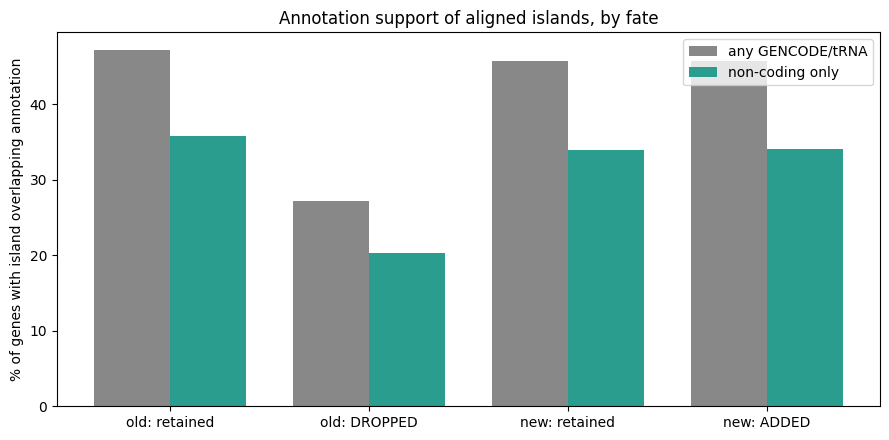

In [133]:
# E3 — DECISIVE: do dropped islands overlap real annotation less than kept ones?
def grp_rates(df):
    g = df.groupby('grp')
    return pd.DataFrame({
        'genes': g.size(),
        'any_overlap%': (100*g['any'].mean()).round(1),
        '>=50pct%': (100*g.o50.mean()).round(1),
        'any_noncoding%': (100*g.any_nc.mean()).round(1),
        '>=50pct_nc%': (100*g.o50_nc.mean()).round(1),
    })

print('OLD (RNA-FM) aligned islands, split by whether RiNALMo kept the gene:')
print(grp_rates(ov_old))
print('\nNEW (RiNALMo) aligned islands, split by whether the gene was already in old:')
print(grp_rates(ov_new))
print(f"\noverall any-overlap:  old {100*ov_old['any'].mean():.1f}%   new {100*ov_new['any'].mean():.1f}%")
print(f"overall non-coding :  old {100*ov_old.any_nc.mean():.1f}%   new {100*ov_new.any_nc.mean():.1f}%")

ord_o = ['retained (shared)', 'dropped (old-only)']
ord_n = ['retained (shared)', 'added (new-only)']
ro, rn = grp_rates(ov_old).reindex(ord_o), grp_rates(ov_new).reindex(ord_n)
fig, ax = plt.subplots(figsize=(9, 4.5))
labels = ['old: retained', 'old: DROPPED', 'new: retained', 'new: ADDED']
any_v = [ro.loc[ord_o[0], 'any_overlap%'], ro.loc[ord_o[1], 'any_overlap%'], rn.loc[ord_n[0], 'any_overlap%'], rn.loc[ord_n[1], 'any_overlap%']]
nc_v  = [ro.loc[ord_o[0], 'any_noncoding%'], ro.loc[ord_o[1], 'any_noncoding%'], rn.loc[ord_n[0], 'any_noncoding%'], rn.loc[ord_n[1], 'any_noncoding%']]
x = np.arange(4); w = .38
ax.bar(x-w/2, any_v, w, label='any GENCODE/tRNA', color='#888')
ax.bar(x+w/2, nc_v, w, label='non-coding only', color='#2A9D8F')
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel('% of genes with island overlapping annotation')
ax.set_title('Annotation support of aligned islands, by fate'); ax.legend()
plt.tight_layout(); plt.show()

distinct annotation transcripts hit by an aligned island:
  any GENCODE/tRNA: old=19,355  new=14,154  shared=6,874  old-only=12,481  new-only=7,280  new/old=0.73
  non-coding only: old=14,210  new=10,223  shared=4,840  old-only=9,370  new-only=5,383  new/old=0.72

Of the 14,210 non-coding features RNA-FM recovered, RiNALMo keeps 4,840 (34.1%)
and adds 5,383 that RNA-FM missed.


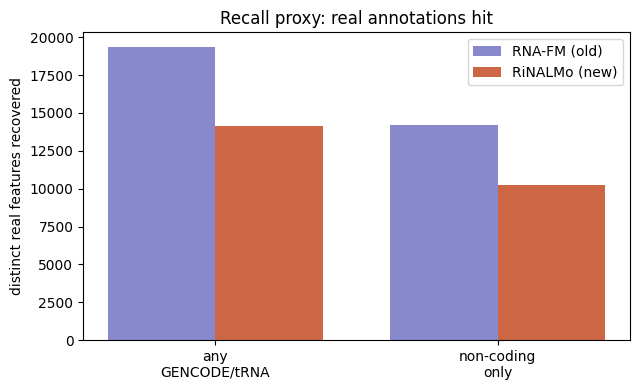

In [134]:
# E4 — recall proxy: distinct REAL mm39 features recovered (any island lands on them)
def rec(a, b, lbl):
    print(f'{lbl}: old={len(a):,}  new={len(b):,}  shared={len(a & b):,}  '
          f'old-only={len(a-b):,}  new-only={len(b-a):,}  new/old={len(b)/max(1,len(a)):.2f}')

print('distinct annotation transcripts hit by an aligned island:')
rec(hits_old, hits_new, '  any GENCODE/tRNA')
rec(hits_nc_old, hits_nc_new, '  non-coding only')

cap = len(hits_nc_old & hits_nc_new)
print(f"\nOf the {len(hits_nc_old):,} non-coding features RNA-FM recovered, RiNALMo keeps {cap:,} ({100*cap/len(hits_nc_old):.1f}%)")
print(f"and adds {len(hits_nc_new - hits_nc_old):,} that RNA-FM missed.")

fig, ax = plt.subplots(figsize=(6.5, 4))
cats = ['any\nGENCODE/tRNA', 'non-coding\nonly']
ov = [len(hits_old), len(hits_nc_old)]; nv = [len(hits_new), len(hits_nc_new)]
x = np.arange(2); w = .38
ax.bar(x-w/2, ov, w, label=OLD_LBL, color=C_OLD)
ax.bar(x+w/2, nv, w, label=NEW_LBL, color=C_NEW)
ax.set_xticks(x); ax.set_xticklabels(cats)
ax.set_ylabel('distinct real features recovered'); ax.set_title('Recall proxy: real annotations hit'); ax.legend()
plt.tight_layout(); plt.show()

### E. Verdict — the drop is mostly *dropped noise*, and precision goes up

**1. Precision proxy rises.** Any-annotation overlap of the final aligned islands goes **34.8% → 45.8%** (non-coding-only 26.2% → 34.1%). RiNALMo's islands are more likely to sit on something real.

**2. The decisive split is unambiguous.** Partitioning RNA-FM's islands by what RiNALMo did with the gene:
- islands RiNALMo **dropped**: only **27%** overlap annotation (20% non-coding)
- islands RiNALMo **kept**: **47%** (36% non-coding)

 The dropped population is depleted ~2× in annotation support — i.e. RiNALMo is shedding the islands least likely to be real. And the genes it **adds** (46% overlap) are as well-supported as the ones it keeps, so they are not junk.

**3. Recall is largely preserved, with turnover.** RiNALMo recovers **72%** as many distinct real non-coding features as RNA-FM *and* adds **5,383** that RNA-FM missed — so total coverage of real annotation is comparable, not collapsed. The two models share only ~4.8k features exactly; some of that turnover is isoform-level (a ~100 bp footprint shifting slightly hits a different annotated isoform), so feature-level turnover overstates the biological difference — the gene-level and precision results above are the robust signal.

**Answer to the question:** *fewer islands = dropped noise + precision gain*, not lost recall. The ~2× reduction is concentrated in low-annotation-support islands; real-annotation coverage holds up and the surviving/added calls land on real features at a higher rate.

> **Caveats.** Absolute overlap rates are modest (~35–46%) because islands are ~100–150 bp footprints and many lncRNA loci are poorly annotated in mm39 — so read the *old-vs-new contrast*, not the absolute level. 'Any GENCODE' truth includes protein-coding neighbours; the non-coding-only column controls for that and tells the same story. This is annotation-overlap, a proxy for precision/recall — not a curated ortholog truth set (that is the `[[ncrna-orthology-oracle]]` direction).

## F. Marquee lncRNAs — the can't-miss controls

MALAT1, NEAT1, XIST, HOTAIR, H19, MEG3, GAS5, BISPR, KCNQ1OT1, XACT are deeply conserved, well-characterised lncRNAs — if the pipeline is healthy they *must* survive from hg38→mm39. This is the sharpest go/no-go signal: if these still get strong island matches under RiNALMo, scaling to 20 mammals is reasonable; if any silently drop out, that points at tuning first.

Per gene, old vs new: reference islands scanned, query islands, matched pairs, best/median match distance (scale differs across models — compare *within* a model), whether it survives to the final aligned output, and whether that island overlaps real mm39 annotation.

In [135]:
# F1 — per-gene old-vs-new scorecard for the marquee lncRNAs
MARQUEE = {'MALAT1':'ENSG00000251562','NEAT1':'ENSG00000245532','XIST':'ENSG00000229807',
          'HOTAIR':'ENSG00000228630','H19':'ENSG00000130600','MEG3':'ENSG00000214548',
          'GAS5':'ENSG00000234741','BISPR':'ENSG00000282851','KCNQ1OT1':'ENSG00000269821',
          'XACT':'ENSG00000241743'}

# precompute gene columns on the raw island frames
for df in (rr_old, rr_new, rq_old, rq_new):
    df['gene'] = df.name.map(H.gene_of_raw)

def uid_for(base, *pools):
    pre = 'U_' + base
    for pool in pools:
        for g in pool:
            if g == pre or g.startswith(pre + '.'):
                return g
    return None

def side(uid_pool, aln, aq, rr, rq, ov):
    uid = uid_for(base, uid_pool)
    if uid is None:
        return dict(uid=None, ref_isl=0, q_isl=0, matches=0, best='-', med='-', final='NO', ann='-')
    a = aln[aln.gene_id == uid]
    ovr = ov.set_index('gene')
    in_final = uid in set(aq.gene)
    ann = '-'
    if uid in ovr.index:
        r = ovr.loc[uid]
        ann = ('yes' if bool(r['any']) else 'no') + ('/nc' if bool(r['any_nc']) else '')
    return dict(uid=uid,
                ref_isl=int((rr.gene == uid).sum()),
                q_isl=int((rq.gene == uid).sum()),
                matches=len(a),
                best=(f"{a.diag_mmd.min():.3f}" if len(a) else '-'),
                med=(f"{a.diag_mmd.median():.3f}" if len(a) else '-'),
                final=('YES' if in_final else 'NO'),
                ann=ann)

pool_o = set(aln_old.gene_id) | set(aq_old.gene) | set(rr_old.gene)
pool_n = set(aln_new.gene_id) | set(aq_new.gene) | set(rr_new.gene)
rows = []
for name, base in MARQUEE.items():
    o = side(pool_o, aln_old, aq_old, rr_old, rq_old, ov_old)
    n = side(pool_n, aln_new, aq_new, rr_new, rq_new, ov_new)
    rows.append([name, o['ref_isl'], n['ref_isl'], o['q_isl'], n['q_isl'],
                 o['matches'], n['matches'], o['best'], n['best'], o['med'], n['med'],
                 o['final'], n['final'], o['ann'], n['ann']])
cols = ['gene','refIsl_o','refIsl_n','qIsl_o','qIsl_n','match_o','match_n',
        'best_o','best_n','med_o','med_n','final_o','final_n','ann_o','ann_n']
mq = pd.DataFrame(rows, columns=cols)
pd.set_option('display.max_columns', 40); pd.set_option('display.width', 200)
print('Marquee lncRNAs, RNA-FM (o) vs RiNALMo (n)  [distances: compare within a model only]')
print(mq.to_string(index=False))

Marquee lncRNAs, RNA-FM (o) vs RiNALMo (n)  [distances: compare within a model only]
    gene  refIsl_o  refIsl_n  qIsl_o  qIsl_n  match_o  match_n best_o best_n med_o med_n final_o final_n  ann_o  ann_n
  MALAT1         3         6       0       0        2        4  0.031  0.013 0.056 0.025     YES     YES yes/nc yes/nc
   NEAT1        35         0       0       0       19        0  0.012      - 0.080     -     YES      NO yes/nc      -
    XIST        13        13       0       0        5        4  0.060  0.022 0.074 0.054     YES     YES yes/nc yes/nc
  HOTAIR         4         2       0       0        1        1  0.033  0.017 0.033 0.017     YES     YES yes/nc yes/nc
     H19         5         4       0       0        4        1  0.035  0.012 0.070 0.012     YES     YES yes/nc yes/nc
    MEG3        11         2       0       0        6        2  0.000  0.041 0.081 0.042     YES     YES yes/nc yes/nc
    GAS5         7         5       0       0        3        2  0.011  0.029 0.034

In [136]:
# F2 — survival summary + NEAT1 drill-down (the one regression)
import json
# marquee genes actually present in the reference union (so absence = real regression, not 'never there')
umeta = pd.read_csv(NEW/'reference_union_transcripts_metadata.tsv', sep='\t')
in_ref = {name: any(umeta.transcript_id.str.startswith('U_'+base)) for name, base in MARQUEE.items()}
surv = mq.set_index('gene')
print('marquee gene in reference union?', {k: v for k, v in in_ref.items()})
print()
for name in MARQUEE:
    o, n, ref = surv.loc[name, 'final_o'], surv.loc[name, 'final_n'], in_ref[name]
    flag = ''
    if ref and o == 'YES' and n == 'NO':
        flag = '   <-- REGRESSION (lost under RiNALMo)'
    elif not ref:
        flag = '   (not in mm-projectable reference; e.g. primate-specific)'
    print(f'  {name:9s} in_ref={ref!s:5s}  final: {o:3s} -> {n:3s}{flag}')

# NEAT1 drill-down: is it a FINDING failure?
uid = umeta.loc[umeta.transcript_id.str.startswith('U_ENSG00000245532'), 'transcript_id'].iloc[0]
pp = json.load(open(NEW/'preprocessed_reference_data.json'))
print(f'\nNEAT1 = {uid} (biotype lncRNA), in reference union: True')
print(f'  RNA-FM raw reference islands : {int((rr_old.gene==uid).sum())}')
print(f'  RiNALMo raw reference islands: {int((rr_new.gene==uid).sum())}')
print(f'  present in RiNALMo preprocessed_reference_data.json (scan output)? {uid in pp}')
print('  => the RiNALMo *reference scanner* returns 0 islands for NEAT1, so it is dropped')
print('     before matching. This is a finding-sensitivity gap, not a matching problem.')
print('     (MALAT1, the neighbouring paraspeckle lncRNA, went 3 -> 6 islands, so it is NEAT1-specific.)')

marquee gene in reference union? {'MALAT1': True, 'NEAT1': True, 'XIST': True, 'HOTAIR': True, 'H19': True, 'MEG3': True, 'GAS5': True, 'BISPR': True, 'KCNQ1OT1': True, 'XACT': True}

  MALAT1    in_ref=True   final: YES -> YES
  NEAT1     in_ref=True   final: YES -> NO    <-- REGRESSION (lost under RiNALMo)
  XIST      in_ref=True   final: YES -> YES
  HOTAIR    in_ref=True   final: YES -> YES
  H19       in_ref=True   final: YES -> YES
  MEG3      in_ref=True   final: YES -> YES
  GAS5      in_ref=True   final: YES -> YES
  BISPR     in_ref=True   final: NO  -> NO 
  KCNQ1OT1  in_ref=True   final: YES -> YES
  XACT      in_ref=True   final: NO  -> NO 

NEAT1 = U_ENSG00000245532.13 (biotype lncRNA), in reference union: True
  RNA-FM raw reference islands : 35
  RiNALMo raw reference islands: 0
  present in RiNALMo preprocessed_reference_data.json (scan output)? False
  => the RiNALMo *reference scanner* returns 0 islands for NEAT1, so it is dropped
     before matching. This is a find

### F. Verdict — one concrete thing to tune before scaling

**7 of 8 projectable marquee lncRNAs survive, several improve.** MALAT1, XIST, HOTAIR, H19, MEG3, GAS5, KCNQ1OT1 all keep strong island matches; within-model best distances are actually *tighter* under RiNALMo (MALAT1 0.031->0.013, XIST 0.060->0.022, H19 0.035->0.012). BISPR/XACT produce no islands under **either** model (XACT is primate-specific; not a RiNALMo regression). So matching + the general behaviour is healthy.

**The exception is decisive: NEAT1 disappears entirely.** The RiNALMo *reference scanner* finds 0 islands in NEAT1 (35 under RNA-FM) and drops it before matching. NEAT1 is one of the most conserved, most structured lncRNAs in the genome (paraspeckle scaffold) — a healthy pipeline cannot silently lose it. Its neighbour MALAT1 gained islands, so this is NEAT1-specific finding sensitivity, not a global threshold that's simply too high.

**Answer to (1) scale-to-20 vs (2) tune:** **tune first — narrowly.** Not a broad recalibration (the aggregate story in A–E is good and precision is up), but the finding stage has at least one real sensitivity hole that a can't-miss control exposes. Scaling to 20 mammals now would propagate that hole into every genome and waste the compute. NEAT1 is the ideal fixture: a single reference gene, scannable in seconds, with a known-good RNA-FM result (35 islands) to target.

**Concrete next step:** re-run the RiNALMo reference scanner on NEAT1 alone and inspect the per-window signal/noise probabilities (from `build_rinalmo_finding.py` / the finding PCA-64 + logreg). Is NEAT1 scoring just under prob=0.5 everywhere (threshold too strict), or genuinely flat (finding classifier blind to its architecture)? That distinguishes a cheap threshold/stride fix from a classifier-retraining need — and gives a fixture to add to `notebooks/finding_benchmark.ipynb`. Only after NEAT1 (and a quick re-check of the other marquee genes) is the 20-mammal run worth launching.